# Supplementary Material:
# Thermodynamic consistency tests for Isobaric Vapor-Liquid Equilibria of Dibutyl Ether + Butan-1-ol Binary Mixture.

*Juan M. Uceda, Marcela Cartes and Andrés Mejía*

This notebook is used to compute the liquid viscosity of pure fluids and the binary mixture using the Helmholtz scaling theory coupled with the SAFT-VR Mie.
This notebook uses an external Excel file (dbe-1butanol.xlsx) which contains the experimental data and the SGTPy suite, which is free download at https://pypi.python.org/pypi/sgtpy/

For further details and thermodynamical properties of pure fluids, the reader is redirected to “Measurements and Theoretical Modeling of Isobaric Vapor-Liquid Equilibria and Dynamic Viscosity for the Dibutyl Ether and Butan-1-ol Binary Mixture” by J. M. Uceda, M. Cartes and A. Mejía. Journal of Chemical & Engineering Data (2025)- Under Review

In [2]:
def visc_hs(component, T):
    '''
    calculate the dynamic viscosity of a hard-sphere fluid.
    
    Parameters
    ----------
    component : object
        :class:`SGTPy.component` object
    T: temperature in K

    Returns
    -------
    visc: dynamic viscosity in mPa*s
    '''
    
    kb = 1.3806488e-23  # Boltzman's constant, J/K
    Na = 6.022142e23  # Avogadro's number, mol^{-1}
    Tr = T/(component.eps/kb)
    import math
    Omega = 1.16145/Tr**0.14874+0.52487/np.exp(0.7732*Tr)+2.16178/np.exp(2.43787*Tr)-6.435e-04*Tr**0.14874*math.sin(18.0323*Tr**(-0.7683)-7.27371) # Neufeld et al.'s empirical correlation
    eta = 5000/16*np.sqrt(component.Mw/1000*kb*T/Na/math.pi)/component.sigma**2/Omega # Chapman-Enskog equation for the viscosity of a hard-sphere gas
    
    return eta

def CMie(component):
    '''
    calculate parameter C in the Mie potential for a pure component.
    
    Parameters
    ----------
    component : object
        :class:`SGTPy.component` object

    Returns
    -------
    C: C-parameter (dimensionless)
    '''
    
    CMie = component.lambda_r/(component.lambda_r-component.lambda_a)*(component.lambda_r/component.lambda_a)**(component.lambda_a/(component.lambda_r-component.lambda_a))
    
    return CMie


def deff(component, T):
    '''
    calculate the effective diameter according to Barker-Henderson's perturbation theory for soft-core potentials.
    
    Parameters
    ----------
    component : object
        :class:`SGTPy.component` object
    T: temperature in K

    Returns
    -------
    deff: effective diameter in meter
    '''
    kb = 1.3806488e-23  # Boltzman's constant, J/K
    from scipy import integrate
    import numpy as np
    umie = lambda r: CMie(component)*(component.eps/kb)*((component.sigma/r)**component.lambda_r-(component.sigma/r)**component.lambda_a)
    func = lambda r: 1-np.exp(-1/T*umie(r))
    deff = integrate.quadrature(func, 0.0, component.sigma)
    
    return deff

In [3]:
def Ascaling_obj(C, component, Texp, P, viscexp):
    kb = 1.3806488e-23  # Boltzman's constant, J/K
    Na = 6.022142e23  # Avogadro's number, mol^{-1}
    R = Na*kb
    eos = saftvrmie(component)
    n = len(Texp)
    vischs = np.zeros_like(Texp)
    da = np.zeros_like(Texp)
    for i in range(n):
        rhol = eos.density(Texp[i], P, 'L')
        vres = 1/rhol-8.314*Texp[i]/P
        sres = eos.EntropyR(Texp[i], P, 'L')
        hres = eos.EnthalpyR(Texp[i], P, 'L')
        ares = (hres-P*vres-Texp[i]*sres)/R/Texp[i]
        d = deff(component, Texp[i])
        rholn = rhol*Na
        rhos = rholn*component.ms
        import math
        eta = rhos*math.pi*d[0]**3/6
        areshs = (4*eta-3*eta**2)/(1-eta)**2
        vischs[i] = visc_hs(component, Texp[i])
        da[i] = ares-areshs
    Trexp = Texp/(component.eps/kb)
    f = Trexp**C[0]
    visc = (np.exp(C[1]+C[2]*(f*da)+C[3]*(f*da)**2+C[4]*(f*da)**3))*vischs
    error = 1/len(viscexp)*np.sum(abs(visc-viscexp)/viscexp)
    return error

def fit_Ascaling(component, Texp, P, viscexp, c0=[0, 0, 0, 0, 0]):
    from scipy.optimize import minimize
    fit = minimize(Ascaling_obj, c0, args=(component, Texp, P, viscexp), method='Nelder-Mead')
    return fit

In [4]:
def visco_Ascaling(component, T, P, theta, C1, C2, C3, C4):
    kb = 1.3806488e-23  # Boltzman's constant, J/K
    Na = 6.022142e23  # Avogadro's number, mol^{-1}
    R = Na*kb
    eos = saftvrmie(component)
    n = len(T)
    vischs = np.zeros_like(T)
    da = np.zeros_like(T)
    for i in range(n):
        rhol = eos.density(T[i], P, 'L')
        vres = 1/rhol-8.314*T[i]/P
        sres = eos.EntropyR(T[i], P, 'L')
        hres = eos.EnthalpyR(T[i], P, 'L')
        ares = (hres-P*vres-T[i]*sres)/R/T[i]
        d = deff(component, T[i])
        rholn = rhol*Na
        rhos = rholn*component.ms
        import math
        eta = rhos*math.pi*d[0]**3/6
        areshs = (4*eta-3*eta**2)/(1-eta)**2
        vischs[i] = visc_hs(component, T[i])
        da[i] = ares-areshs
    Tr = T/(component.eps/kb)
    f = Tr**theta
    visc = (np.exp(C1+C2*(f*da)+C3*(f*da)**2+C4*(f*da)**3))*vischs
    return visc

In [5]:
#read dynamic viscosity data: pure DBE
import pandas as pd
dfvisco1 = pd.read_excel('dbe-1butanol.xlsx', sheet_name='viscpure_1')
T1exp = dfvisco1['T/K'].to_numpy()
visco1exp = dfvisco1['visco/mPa*s'].to_numpy()
dfvisco1.head(n=16)

,T/K,visco/mPa*s
0,243.15,1.7336
1,253.15,1.3786
2,263.15,1.1256
3,273.15,0.9420
4,283.15,0.8032
5,293.15,0.6906
6,303.15,0.6080
7,313.15,0.5388
8,323.15,0.4805
9,333.15,0.4326


In [6]:
#read dynamic viscosity data: pure nbOH
dfvisco2 = pd.read_excel('dbe-1butanol.xlsx', sheet_name='viscpure_2')
T2exp = dfvisco2['T/K'].to_numpy()
visco2exp = dfvisco2['visco/mPa*s'].to_numpy()
dfvisco2.head(n=16)

,T/K,visco/mPa*s
0,298.15,2.5710
1,303.15,2.2630
2,313.15,1.7734
3,323.15,1.4099
4,333.15,1.1357
5,343.15,0.9260
6,353.15,0.7630
7,363.15,0.6350
8,373.15,0.5340
9,383.15,0.4520


In [7]:
#read dynamic viscosity data
dfvisco = pd.read_excel('dbe-1butanol.xlsx', sheet_name='dyn_vis')
x1exp = dfvisco['x1'].to_numpy()
viscoexp = dfvisco['dvis/mPa*s'].to_numpy()
dfvisco.head(n=14)

,x1,dvis/mPa*s
0,0.000,2.588
1,0.044,2.301
2,0.097,1.981
3,0.195,1.564
4,0.303,1.252
5,0.414,1.038
6,0.523,0.891
7,0.602,0.813
8,0.706,0.737
9,0.811,0.681


In [10]:
import numpy as np
from sgtpy import component, mixture, saftvrmie
P = 101300
DBE = component('DBE', ms=2.9326, sigma=4.3581, eps=363.107, lambda_r=17.4657, lambda_a=6, eAB=2500, rcAB=0.280, 
                sites=[0,0,1], npol=4.3989, mupol=1.17, Mw=130.23)
nbOH = component('nbOH', ms=2.4614, sigma=3.7704, eps=266.49, lambda_r=11.338, lambda_a=6, eAB=2910.05, rcAB=0.3042, 
                 rdAB=0.4, npol=0, mupol = 1.66, sites=[1,0,1], Mw=74.12)
#Ascaling1 = fit_Ascaling(DBE, T1exp, P, visco1exp, c0=[1.5, 1, 0, 0, 0])
#Ascaling2 = fit_Ascaling(nbOH, T2exp, P, visco2exp, c0=[1.5, 1, 0, 0, 0])
#print(Ascaling1)
#print("")
#print(Ascaling2)
#print("")

In [11]:
T = np.array(np.linspace(200, 400, num=201))
P = 101300
visco1 = visco_Ascaling(DBE, T, P, 1.35758423e+00,  2.45695218e+00,  3.03084259e-04, -9.33354254e-04, -6.11666224e-03)
visco2 = visco_Ascaling(nbOH, T, P, 1.5, 2.31678874e+00, -1.12113793e-02,  2.98635440e-02,  -4.01476417e-05)

/var/folders/k_/kxwtgjhd0_g7573m8sw0_8100000gn/T/ipykernel_26891/1593385668.py:63: DeprecationWarning: `scipy.integrate.quadrature` is deprecated as of SciPy 1.12.0and will be removed in SciPy 1.15.0. Please use`scipy.integrate.quad` instead.
  deff = integrate.quadrature(func, 0.0, component.sigma)


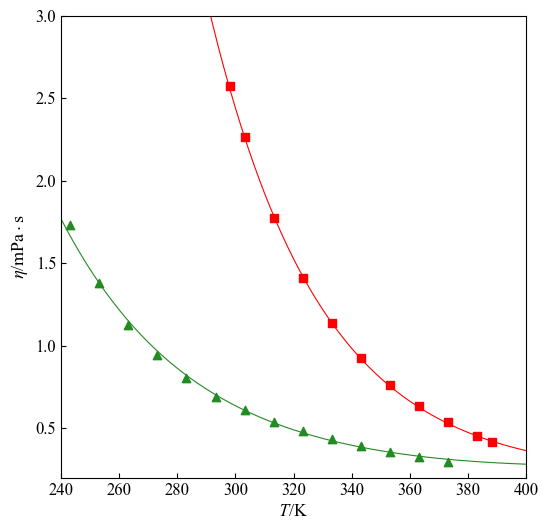

In [12]:
import matplotlib.pylab as plt
plt.rc('text', usetex=False )
plt.rc('font', family="Times New Roman", weight='normal', size=12)
plt.rcParams['mathtext.fontset'] = 'custom'
plt.rcParams['mathtext.rm'] = 'Times New Roman'
plt.rcParams['mathtext.it'] = 'Times New Roman:italic'
plt.rcParams['mathtext.bf'] = 'Times New Roman:bold'
fig = plt.figure(figsize=(6,6))
plt.tick_params(direction='in')
plt.scatter(T1exp, visco1exp, marker='^', color='ForestGreen', clip_on=False, zorder=10, label='_nolegend_')
plt.scatter(T2exp, visco2exp, marker='s', color='red', clip_on=False, zorder=10, label='_nolegend_')
plt.plot(T, visco1, linestyle='solid', linewidth=0.8, color='ForestGreen', label='_nolegend_')
plt.plot(T, visco2, linestyle='solid', linewidth=0.8, color='red', label='_nolegend_')
plt.xlabel('$T$/K', fontsize=13)
plt.ylabel(r'$\eta/\mathrm{mPa\cdot s}$', fontsize=13)
plt.ylim([0.2, 3])
plt.xlim([240, 400])
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
plt.show()

In [10]:
fig.savefig("vis_purefluids.pdf", bbox_inches='tight')

In [13]:
def viscomix_Ascaling(component1, component2, T, P, X, matcoeff1, matcoeff2):
    import math
    kb = 1.3806488e-23  # Boltzman's constant, J/K
    Na = 6.022142e23  # Avogadro's number, mol^{-1}
    R = Na*kb
    mix = mixture(component1, component2)
    Kij = np.array([[0, -0.00959149], 
                [-0.00959149, 0]])
    Lij = np.array([[0, 0.1409278], 
                [0.1409278, 0]])
    mix.kij_saft(Kij)
    mix.lij_saft(Lij)
    eos = saftvrmie(mix)
    
    theta1 = matcoeff1[0]
    a1 = matcoeff1[1]
    b1 = matcoeff1[2]
    c1 = matcoeff1[3]
    d1 = matcoeff1[4]
    theta2 = matcoeff2[0]
    a2 = matcoeff2[1]
    b2 = matcoeff2[2]
    c2 = matcoeff2[3]
    d2 = matcoeff2[4]
    
    rhol = eos.density(X, T, P, 'L')
    vres = 1/rhol-kb*Na*T/P
    sres = eos.EntropyR(X, T, P, 'L')
    hres = eos.EnthalpyR(X, T, P, 'L')
    ares = (hres-P*vres-T*sres)/R/T
    xs1 = DBE.ms*X[0]/(DBE.ms*X[0]+nbOH.ms*X[1])
    xs2 = 1-xs1
    rholn = rhol*Na
    rhos = rholn*(DBE.ms*X[0]+nbOH.ms*X[1])
    d11 = deff(DBE, T)
    d22 = deff(nbOH, T)
    zeta0 = math.pi*rhos/6*(xs1+xs2)
    zeta1 = math.pi*rhos/6*(xs1*d11[0]+xs2*d22[0])
    zeta2 = math.pi*rhos/6*(xs1*d11[0]**2+xs2*d22[0]**2)
    zeta3 = math.pi*rhos/6*(xs1*d11[0]**3+xs2*d22[0]**3)
    zeta4 = math.pi*rhos/6*(xs1*d11[0]**4+xs2*d22[0]**4)
    areshs = 6/math.pi/rhos*((zeta2**3/zeta3**2-zeta0)*np.log(1-zeta3)+3*zeta1*zeta2/(1-zeta3)+zeta2**3/zeta3/(1-zeta3)**2)
    da = ares-areshs
    avgm = X[0]*component1.ms+X[1]*component2.ms
    am = X[0]*a1+X[1]*a2
    Tr1 = T/(component1.eps/kb)
    Tr2 = T/(component2.eps/kb)
    f1 = Tr1**theta1
    f2 = Tr2**theta2
    bm = X[0]*b1*f1*component1.ms/avgm*da+X[1]*b2*f2*component2.ms/avgm*da
    cm = X[0]*c1*(f1*component1.ms/avgm*da)**2+X[1]*c2*(f2*component2.ms/avgm*da)**2
    dm = X[0]*d1*(f1*component1.ms/avgm*da)**3+X[1]*d2*(f2*component2.ms/avgm*da)**3
    visc1hs = visc_hs(component1, T)
    visc2hs = visc_hs(component2, T)
    fi11 = 1
    fi22 = fi11
    fi12 = (1+(visc1hs/visc2hs)**(1/2)*(component2.Mw/component1.Mw)**(1/4))**2/np.sqrt(8*(1+component1.Mw/component2.Mw))
    fi21 = (1+(visc2hs/visc1hs)**(1/2)*(component1.Mw/component2.Mw)**(1/4))**2/np.sqrt(8*(1+component2.Mw/component1.Mw))
    viscmhs = X[0]*visc1hs/(X[0]*fi11+X[1]*fi12)+X[1]*visc2hs/(X[0]*fi21+X[1]*fi22)
    viscm = np.exp(am+bm+cm+dm)*viscmhs
    
    return viscm

In [14]:
T0 = 298.15
P0 = 101300
coeff1 = np.array([1.35758423e+00,  2.45695218e+00,  3.03084259e-04, -9.33354254e-04, -6.11666224e-03])
coeff2 = np.array([1.5, 2.31678874e+00, -1.12113793e-02,  2.98635440e-02,  -4.01476417e-05])
X = np.array([np.linspace(0.00, 1.00, num=100), np.linspace(1.00, 0.00, num=100)])
n = len(X[0])
viscm = np.zeros_like(X[0])
for i in range(n):
    viscm[i] = viscomix_Ascaling(DBE, nbOH, T0, P0, X[:,i], coeff1, coeff2)

/var/folders/k_/kxwtgjhd0_g7573m8sw0_8100000gn/T/ipykernel_26891/1593385668.py:63: DeprecationWarning: `scipy.integrate.quadrature` is deprecated as of SciPy 1.12.0and will be removed in SciPy 1.15.0. Please use`scipy.integrate.quad` instead.
  deff = integrate.quadrature(func, 0.0, component.sigma)


In [13]:
def viscomix_Ascaling(component1, component2, T, P, X, matcoeff1, matcoeff2):
    import math
    kb = 1.3806488e-23  # Boltzman's constant, J/K
    Na = 6.022142e23  # Avogadro's number, mol^{-1}
    R = Na*kb
    mix = mixture(component1, component2)
    Kij = np.array([[0, -0.00959149], 
                [-0.00959149, 0]])
    Lij = np.array([[0, 0.1409278], 
                [0.1409278, 0]])
    mix.kij_saft(Kij)
    mix.lij_saft(Lij)
    eos = saftvrmie(mix)
    
    theta1 = matcoeff1[0]
    a1 = matcoeff1[1]
    b1 = matcoeff1[2]
    c1 = matcoeff1[3]
    d1 = matcoeff1[4]
    theta2 = matcoeff2[0]
    a2 = matcoeff2[1]
    b2 = matcoeff2[2]
    c2 = matcoeff2[3]
    d2 = matcoeff2[4]
    
    rhol = eos.density(X, T, P, 'L')
    vres = 1/rhol-kb*Na*T/P
    sres = eos.EntropyR(X, T, P, 'L')
    hres = eos.EnthalpyR(X, T, P, 'L')
    ares = (hres-P*vres-T*sres)/R/T
    xs1 = DBE.ms*X[0]/(DBE.ms*X[0]+nbOH.ms*X[1])
    xs2 = 1-xs1
    rholn = rhol*Na
    rhos = rholn*(DBE.ms*X[0]+nbOH.ms*X[1])
    d11 = deff(DBE, T)
    d22 = deff(nbOH, T)
    zeta0 = math.pi*rhos/6*(xs1+xs2)
    zeta1 = math.pi*rhos/6*(xs1*d11[0]+xs2*d22[0])
    zeta2 = math.pi*rhos/6*(xs1*d11[0]**2+xs2*d22[0]**2)
    zeta3 = math.pi*rhos/6*(xs1*d11[0]**3+xs2*d22[0]**3)
    zeta4 = math.pi*rhos/6*(xs1*d11[0]**4+xs2*d22[0]**4)
    areshs = 6/math.pi/rhos*((zeta2**3/zeta3**2-zeta0)*np.log(1-zeta3)+3*zeta1*zeta2/(1-zeta3)+zeta2**3/zeta3/(1-zeta3)**2)
    da = ares-areshs
    avgm = X[0]*component1.ms+X[1]*component2.ms
    am = X[0]*a1+X[1]*a2
    Tr1 = T/(component1.eps/kb)
    Tr2 = T/(component2.eps/kb)
    f1 = Tr1**theta1
    f2 = Tr2**theta2
    bm = X[0]*b1*f1*component1.ms/avgm*da+X[1]*b2*f2*component2.ms/avgm*da
    cm = X[0]*c1*(f1*component1.ms/avgm*da)**2+X[1]*c2*(f2*component2.ms/avgm*da)**2
    dm = X[0]*d1*(f1*component1.ms/avgm*da)**3+X[1]*d2*(f2*component2.ms/avgm*da)**3
    visc1hs = visc_hs(component1, T)
    visc2hs = visc_hs(component2, T)
    fi11 = 1
    fi22 = fi11
    fi12 = (1+(visc1hs/visc2hs)**(1/2)*(component2.Mw/component1.Mw)**(1/4))**2/np.sqrt(8*(1+component1.Mw/component2.Mw))
    fi21 = (1+(visc2hs/visc1hs)**(1/2)*(component1.Mw/component2.Mw)**(1/4))**2/np.sqrt(8*(1+component2.Mw/component1.Mw))
    viscmhs = X[0]*visc1hs/(X[0]*fi11+X[1]*fi12)+X[1]*visc2hs/(X[0]*fi21+X[1]*fi22)
    viscm = np.exp(am+bm+cm+dm)*viscmhs
    
    return viscm

In [15]:
T0 = 298.15
P0 = 101300
coeff1 = np.array([1.35758423e+00,  2.45695218e+00,  3.03084259e-04, -9.33354254e-04, -6.11666224e-03])
coeff2 = np.array([1.5, 2.31678874e+00, -1.12113793e-02,  2.98635440e-02,  -4.01476417e-05])
X = np.array([np.linspace(0.00, 1.00, num=100), np.linspace(1.00, 0.00, num=100)])
n = len(X[0])
viscm0 = np.zeros_like(X[0])
for i in range(n):
    viscm0[i] = viscomix_Ascaling(DBE, nbOH, T0, P0, X[:,i], coeff1, coeff2)

/var/folders/k_/kxwtgjhd0_g7573m8sw0_8100000gn/T/ipykernel_26891/1593385668.py:63: DeprecationWarning: `scipy.integrate.quadrature` is deprecated as of SciPy 1.12.0and will be removed in SciPy 1.15.0. Please use`scipy.integrate.quad` instead.
  deff = integrate.quadrature(func, 0.0, component.sigma)


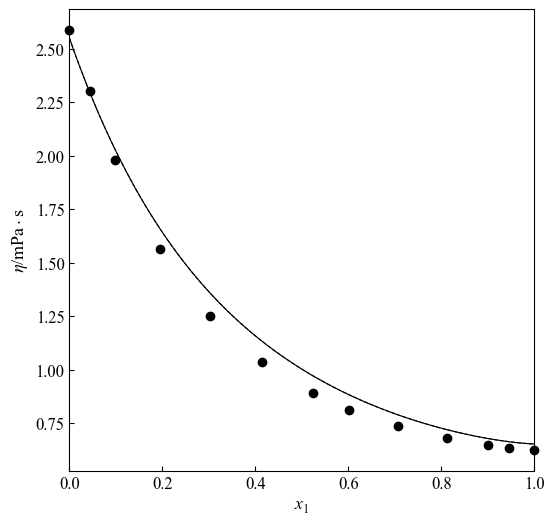

In [16]:
plt.rc('text', usetex=False )
plt.rc('font', family="Times New Roman", weight='normal', size=12)
plt.rcParams['mathtext.fontset'] = 'custom'
plt.rcParams['mathtext.rm'] = 'Times New Roman'
plt.rcParams['mathtext.it'] = 'Times New Roman:italic'
plt.rcParams['mathtext.bf'] = 'Times New Roman:bold'
fig = plt.figure(figsize=(6,6))
plt.tick_params(direction='in')
plt.scatter(x1exp, viscoexp, color='black', clip_on=False, zorder=10)
plt.plot(X[0], viscm, linestyle='solid', linewidth=0.8, color='black')
plt.plot(X[0], viscm0, linestyle='dashed', linewidth=0.8, color='black')
plt.xlabel('$x_1$', fontsize=13)
plt.ylabel(r'$\eta/\mathrm{mPa\cdot s}$', fontsize=13)
plt.xlim([0, 1])
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
plt.show()

In [16]:
fig.savefig("mixvis_dbe-nbOH.pdf", bbox_inches='tight')

In [17]:
Xexp = np.array([x1exp, 1-x1exp])
T0 = 298.15
P0 = 101300
vissaftexp = np.zeros_like(Xexp[0])
n = len(Xexp[0])
for i in range(n):
    vissaftexp[i] = viscomix_Ascaling(DBE, nbOH, T0, P0, Xexp[:,i], coeff1, coeff2)

/var/folders/k_/kxwtgjhd0_g7573m8sw0_8100000gn/T/ipykernel_26891/1593385668.py:63: DeprecationWarning: `scipy.integrate.quadrature` is deprecated as of SciPy 1.12.0and will be removed in SciPy 1.15.0. Please use`scipy.integrate.quad` instead.
  deff = integrate.quadrature(func, 0.0, component.sigma)


In [18]:
AAPD = 100/len(Xexp[0])*np.sum(abs(vissaftexp-viscoexp)/viscoexp)
print(round(AAPD,2))

5.61
